In [56]:
import numpy as n
import matplotlib.pyplot as plot
import pandas as p
data=p.read_csv("ESG_Sustainability_csv.csv")


In [6]:
revenue = data["Revenue_Mission"].values
carbon = data["Carbon_Emission_Tons"].values
renewable = data["Renewable_Energy_Percent"].values
diversity = data["Employee_Diversity_Score"].values
safety = data["Safety_Incidents"].values
governance = data["Governance_Score"].values
satisfaction = data["Employee_Satisfaction"].values
training = data["Training_Hours"].values

KPI

In [8]:
carbon_efficiency=(revenue/carbon)
employee_wellbeing=((satisfaction/satisfaction.max())*60+(training/training.max())*40)*100
esg_score=((renewable/renewable.max())*30+(diversity/diversity.max())*20+(governance/governance.max())*25+(employee_wellbeing/employee_wellbeing.max())*15+(1-safety/safety.max())*10)*100
risk_score=((carbon/carbon.max())*40+(safety/safety.max())*30+(1-governance/governance.max())*30)*100
carbon_intelligence=((revenue/revenue.max())*50+(1-carbon/carbon.max())*50)*100
human_capital=((diversity/diversity.max())*35+(satisfaction/satisfaction.max())*35+(training/training.max())*30)*100
sustainability_momentum=((renewable/renewable.max())*60+(governance/governance.max())*40)*100
esg_innovation=(carbon_intelligence*0.30+human_capital*0.25+sustainability_momentum*0.45)
resilience_score=((1-safety/safety.max())*40+(governance/governance.max())*30+(satisfaction/satisfaction.max())*30)*100
future_risk=((carbon/carbon.max())*35+(safety/safety.max())*35+(1-renewable/renewable.max())*15+(1-governance/governance.max())*15)*100

In [9]:
#Anomaly Detect
threshold=n.mean(risk_score)+2*n.std(risk_score)
high_risk=(risk_score>threshold)

In [10]:
data["Carbon_Effciency"]=n.round(carbon_efficiency,2)
data["Employee_Wellbeing"]=n.round(employee_wellbeing,2)
data["ESG_Score"]=n.round(esg_score,2)
data["Risk_Score"]=n.round(risk_score,2)
data["High_Risk"]=high_risk
data["Carbon_Intelligence"] = n.round(carbon_intelligence,2)
data["Human_Capital"] = n.round(human_capital,2)
data["Sustainability_Momentum"] = n.round(sustainability_momentum,2)
data["ESG_Innovation"] = n.round(esg_innovation,2)
data["Resilience_Score"] = n.round( resilience_score,2)
data["Future_Risk"] = n.round(future_risk,2)

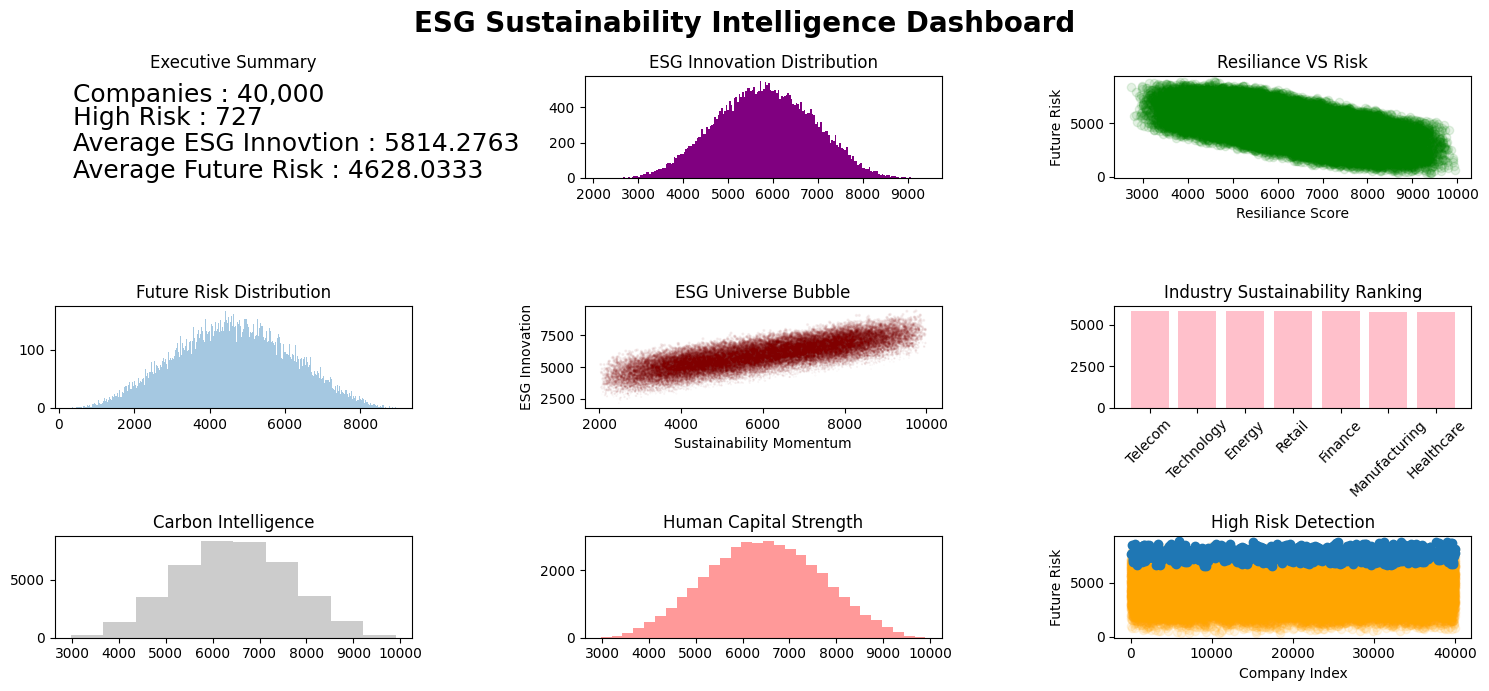

In [53]:
import matplotlib.pyplot as plot
fig=plot.figure(figsize=(15,7))
fig.suptitle("ESG Sustainability Intelligence Dashboard",fontsize=20,fontweight="bold")
plot.subplot(3,3,1)
plot.axis("off")
plot.text(0.05,0.75,f"Companies : {len(data):,}",fontsize=18)
plot.text(0.05,0.52,f"High Risk : {high_risk.sum():,}",fontsize=18)
plot.text(0.05,0.27,f"Average ESG Innovtion : {esg_innovation.mean():.4f}",fontsize=18)
plot.text(0.05,0.00,f"Average Future Risk : {future_risk.mean():.4f}",fontsize=18)
plot.title("Executive Summary")
plot.subplot(3,3,2)
plot.hist(esg_innovation,bins=200,color="purple")
plot.title("ESG Innovation Distribution")
plot.subplot(3,3,3)
plot.scatter(resilience_score,future_risk,alpha=0.1,color="green")
plot.title("Resiliance VS Risk")
plot.xlabel("Resiliance Score")
plot.ylabel("Future Risk")
plot.subplot(3,3,4)
plot.hist(future_risk,bins=600,alpha=0.4)
plot.title("Future Risk Distribution")
plot.subplot(3,3,5)
plot.scatter(sustainability_momentum,esg_innovation,s=revenue/5000,alpha=0.05,color="maroon")
plot.title("ESG Universe Bubble")
plot.xlabel("Sustainability Momentum")
plot.ylabel("ESG Innovation")
plot.subplot(3,3,6)
industry_rank=(data.groupby("Industry")["ESG_Innovation"].mean().sort_values(ascending=False))
plot.bar(industry_rank.index,industry_rank.values,color="pink")
plot.xticks(rotation=45)
plot.title("Industry Sustainability Ranking")
plot.subplot(3,3,7)
plot.hist(human_capital,alpha=0.4,color="gray",bins=10)
plot.title("Carbon Intelligence")
plot.subplot(3,3,8)
plot.hist(human_capital,alpha=0.4,color="red",bins=30)
plot.title("Human Capital Strength")
plot.subplot(3,3,9)
plot.scatter(range(len(data)),future_risk,alpha=0.1,color="orange")
plot.scatter(n.where(high_risk)[0],future_risk[high_risk])
plot.title("High Risk Detection")
plot.xlabel("Company Index")
plot.ylabel("Future Risk")
plot.tight_layout()
plot.show()

In [55]:
data.to_excel(
    "ESG_Analytics_Report.xlsx",
    index=False
)

print("Report Saved Successfully")

Report Saved Successfully
